## 1. XGBoost 개념 및 동작 원리

**XGBoost(Xtreme Gradient Boosting)**란?

Gradient Boosting 알고리즘을 더 빠르고, 더 강력하고, 과적합에 강하게 만든 알고리즘.

데이터 분석 및 캐글 대회에서 가장 많이 사용되는 기법 중 하나.

결정트리(Decision Tree)를 **Weak Learner(약한 학습기)**로 사용하여 여러 개의 트리를 순차적으로 학습시켜 성능을 높임.

XGBoost 핵심 특징
1) Boosting 방식

하나의 트리를 학습한 후 다음 트리는 이전 트리의 오차를 보완하는 방향으로 학습

즉, "틀린 부분을 계속 보완하며 강한 모델" 생성

2) Gradient Boosting 기반

각 반복(iteration)에서 Loss Function(오차)을 줄이도록 Gradient 값을 사용해 트리가 생성됨.

3) 규제(Regularization) 포함

기존 GradientBoosting과 달리 L1, L2 규제를 포함

→ 과적합(Overfitting)을 방지하는 효과

4) 분산 처리 + 빠른 연산

자체적인 최적화(병렬 처리, sparsity 대응 등)로 학습 속도가 매우 빠름

5) Early Stopping 지원

검증셋의 성능이 일정 rounds 동안 좋아지지 않으면 학습 자동 종료
→ 시간 절약 + 과적합 방지

XGBoost의 동작 과정 요약

첫 번째 트리가 데이터 패턴을 학습

예측 오류(residual error = 실제 - 예측)를 계산

두 번째 트리는 이 오류를 줄이도록 학습

계속 반복하며 트리가 추가됨

모든 트리의 예측값을 합쳐 최종 예측
→ 약한 트리들이 모여 강한 예측기가 됨

In [1]:
! pip install xgboost

   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
    --------------------------------------- 1.0/72.0 MB 5.6 MB/s eta 0:00:13
   - -------------------------------------- 2.1/72.0 MB 5.6 MB/s eta 0:00:13
   - -------------------------------------- 3.4/72.0 MB 5.4 MB/s eta 0:00:13
   -- ------------------------------------- 4.5/72.0 MB 5.4 MB/s eta 0:00:13
   --- ------------------------------------ 5.5/72.0 MB 5.4 MB/s eta 0:00:13
   --- ------------------------------------ 6.6/72.0 MB 5.1 MB/s eta 0:00:13
   ---- ----------------------------------- 7.3/72.0 MB 5.0 MB/s eta 0:00:14
   ---- ----------------------------------- 8.4/72.0 MB 5.0 MB/s eta 0:00:13
   ----- ---------------------------------- 9.4/72.0 MB 4.9 MB/s eta 0:00:13
   ----- ---------------------------------- 10.2/72.0 MB 4.9 MB/s eta 0:00:13
   ------ --------------------------------- 11.3/72.0 MB 4.8 MB/s eta 0:00:13
   ------ --------------------------------- 12.6/72.0 MB 4.9 MB/s eta 0:00:13
   

1. 위스콘신 유방암 데이터셋 컬럼 설명

이 데이터는 종양의 세포 핵(nucleus) 모양을 여러 지표로 표현한 것입니다.
각 feature는 다음 10개의 기본 값에 대해,

mean : 평균값

error : 표준오차(측정값의 변동성)

worst : 가장 안 좋은(최대) 값 근처의 평균

을 저장해놨다고 보면 됩니다.

| 컬럼명                        | 의미                           | 쉽게 설명                               |
| -------------------------- | ---------------------------- | ----------------------------------- |
| **mean radius**            | 세포 핵 반지름의 평균                 | 종양 이미지를 봤을 때 **세포 핵 크기의 평균 반경**     |
| **mean texture**           | 그레이스케일 값의 표준편차(질감) 평균        | 밝기 다양성 → **표면 질감의 거칠기/불균일성의 평균**    |
| **mean perimeter**         | 둘레 길이 평균                     | 세포 핵의 **경계 선 길이 평균**                |
| **mean area**              | 면적 평균                        | 세포 핵이 차지하는 **면적의 평균 크기**            |
| **mean smoothness**        | 반지름 길이 변화 정도 평균              | 경계가 **얼마나 매끈한지(=거칠지 않은지)** 평균       |
| **mean compactness**       | (perimeter² / area - 1.0) 평균 | **얼마나 조밀한지/둥근지**를 나타내는 값            |
| **mean concavity**         | 오목한 부분의 심각도 평균               | 경계가 **안쪽으로 파인 정도의 평균**              |
| **mean concave points**    | 오목한 부분의 개수 평균                | 경계가 **안쪽으로 꺾인 지점의 개수 평균**           |
| **mean symmetry**          | 대칭성 평균                       | 세포 모양이 **얼마나 좌우로 대칭적인지** 평균         |
| **mean fractal dimension** | 프랙탈 차원 평균                    | 경계의 복잡도, **“해안선 길이”처럼 복잡할수록 커지는 값** |


| 컬럼명                         | 의미              |
| --------------------------- | --------------- |
| **radius error**            | 반지름 값의 표준오차     |
| **texture error**           | 질감 값의 표준오차      |
| **perimeter error**         | 둘레 값의 표준오차      |
| **area error**              | 면적 값의 표준오차      |
| **smoothness error**        | 매끄러움 값의 표준오차    |
| **compactness error**       | 조밀도 값의 표준오차     |
| **concavity error**         | 오목함 심각도 값의 표준오차 |
| **concave points error**    | 오목 지점 개수의 표준오차  |
| **symmetry error**          | 대칭성 값의 표준오차     |
| **fractal dimension error** | 프랙탈 차원 값의 표준오차  |

| 컬럼명                         | 의미                                |
| --------------------------- | --------------------------------- |
| **worst radius**            | 가장 큰 반지름 값들에서 뽑은 평균 (최악에 가까운 반지름) |
| **worst texture**           | 가장 심한 질감(표준편차) 값들의 평균             |
| **worst perimeter**         | 가장 큰 둘레 값들의 평균                    |
| **worst area**              | 가장 큰 면적 값들의 평균                    |
| **worst smoothness**        | 가장 덜 매끄러운 상태의 평균                  |
| **worst compactness**       | 가장 조밀한(또는 비정상적인) 상태의 평균           |
| **worst concavity**         | 가장 심하게 오목한 상태의 평균                 |
| **worst concave points**    | 가장 오목한 지점이 많은 상태의 평균              |
| **worst symmetry**          | 가장 비대칭적인 상태의 평균                   |
| **worst fractal dimension** | 가장 복잡한 경계 상태의 평균                  |


➡ 요약하면:

mean 계열: 종양 전체의 전반적인 특징

error 계열: 값의 변동성 (안정적인지, 들쭉날쭉한지)

worst 계열: 가장 안 좋은 쪽 특성 (악성 판별에 특히 중요)

In [2]:
import xgboost
print(xgboost.__version__)

3.1.1


In [3]:
import xgboost as xgb                                       # xgboost 알고리즘을 파이썬 환경에서 사용하기 위해 모듈을 xgb라는 이름으로 가져온다
from xgboost import plot_importance                         # 학습된 모델에서 어떤 특징이 중요한지 시각적으로 확인할 수 있는 plot_importance 함수를 가져온다
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer            # 위스콘신 유방암 데이터셋을 불러오기 위한 함수를 import 한다
from sklearn.model_selection import train_test_split       # 전체 데이터를 학습용/테스트용으로 나누기 위한 함수 사용
import warnings                                            # 경고 메시지 무시
warnings.filterwarnings('ignore')


In [5]:
# 유방암 데이터셋을 불러오기
dataset =load_breast_cancer()                                            # 유방암 데이터셋 가져오기
X_features = dataset.data                                                # 가져온 데이터셋에서 입력 변수(feature)만 설정
y_label = dataset.target                                                 # 정답 레이블(target : 악성/양성)을 y_label 변수에 저장

cancer_df = pd.DataFrame(data=X_features, columns=dataset.feature_names)       # 데이터를 pandas dataframe 구조로 변화해서 컬럼명을 부여

cancer_df['target'] = y_label                                                  # DataFrame의 마지막 열에 target 컬럼값을 추가해서 y_label 값 넣어줌

cancer_df.head(10)                                                             # 상위 10개의 데이터만 출력

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0
5,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,0.2087,0.07613,...,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440,0
6,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,0.1794,0.05742,...,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.1932,0.3063,0.08368,0
7,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,0.2196,0.07451,...,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.1556,0.3196,0.11510,0
8,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,0.2350,0.07389,...,30.73,106.20,739.3,0.1703,0.5401,0.5390,0.2060,0.4378,0.10720,0
9,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,0.2030,0.08243,...,40.68,97.65,711.4,0.1853,1.0580,1.1050,0.2210,0.4366,0.20750,0


In [7]:
print(dataset.target_names)                      # 데이터셋이 어떤 레이블을 사용하는지 출력해서 클래스명 확인
                                                 # (malignant : 악성, benign : 양성  --> and 0은 악성 / 1은 양성
print(cancer_df['target'].value_counts())        # 0과1이 각각 몇 개 있는지 출력하여 데이터 분포 확인

['malignant' 'benign']
target
1    357
0    212
Name: count, dtype: int64


In [9]:
X_features = cancer_df.iloc[:, :-1]  # feature 컬럼만 선택하기 위해서 마지막 target 컬럼을 제외한 모든 컬럼 값이 입력 데이터 사용
y_label = cancer_df.iloc[:, -1]      # 마지막 컬럼 target만 선택해서 label 데이터로 사용

In [10]:
X_features

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [11]:
y_label

0      0
1      0
2      0
3      0
4      0
      ..
564    0
565    0
566    0
567    0
568    1
Name: target, Length: 569, dtype: int64

In [13]:
# 전제 데이터에서 80%, 테스트용 20% 비율로 분리
X_train, X_test, y_train, y_test = train_test_split(
    X_features, y_label, test_size=0.2, random_state=156
)

# 전제 데이터에서 90%, 테스트용 10% 비율로 분리하고 모델 튜닝시 활용
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.1, random_state=156
)

print(X_train.shape, X_test.shape)   # 분리된 비율이 맞는지 크기 확인
print(X_tr.shape, X_val.shape)       # 분지된 비율이 맞는지 크기 확인

(455, 30) (114, 30)
(409, 30) (46, 30)


In [14]:
# xgboost가 계산을 최적화하기 위해 사용하는 DMatrix 구조로 학습 데이터를 변환
dtr = xgb.DMatrix(data=X_tr, label=y_tr)           
dval = xgb.DMatrix(data=X_val, label=y_val)         # 검증데이터도 동일하게 변환
dtest = xgb.DMatrix(data=X_test, label=y_test)      # 테스트 데이터도 동일하게 변환

In [20]:
# 모델 학습에 필요한 하이퍼파라메터 설정
params = {              
    'max_depth' : 3,                               # 트리의 깊이를 3개로 제한하여 과적합을 방지
    'eta' : 0.5,                                   # learning rate를 설정하여 한번의 학습 단계에서 조정되는 크기 설정
    'objective' : 'binary:logistic',               # 이진 분류 문제이므로 로지스틱 함수 사용해서 확률로 예측
    'eval_metric' : 'logloss'                      # 평가 지표로서, 로그손실(logloss)을 사용
}

num_rounds = 400                                   # 최대 boosting 반복 횟수 정의

In [21]:
# 학습시, 평가할 데이터를 지정해서 학습과정에서 early stopping에 활용
# --> 데이터셋의 성능이 개선되었거나, 계속 개선되지 않으면 학습을 조기 종료 
eval_list = [(dtr, 'train'), (dval, 'eval')]

xgb_model = xgb.train(
    params=params,
    dtrain=dtr,
    num_boost_round=num_rounds,
    early_stopping_rounds=50,
    evals=eval_list
)

[0]	train-logloss:0.33637	eval-logloss:0.44579
[1]	train-logloss:0.20512	eval-logloss:0.35638
[2]	train-logloss:0.13638	eval-logloss:0.30729
[3]	train-logloss:0.09867	eval-logloss:0.27589
[4]	train-logloss:0.07345	eval-logloss:0.27413
[5]	train-logloss:0.05879	eval-logloss:0.27065
[6]	train-logloss:0.04771	eval-logloss:0.26873
[7]	train-logloss:0.03821	eval-logloss:0.26627
[8]	train-logloss:0.03192	eval-logloss:0.27051
[9]	train-logloss:0.02761	eval-logloss:0.27630
[10]	train-logloss:0.02324	eval-logloss:0.27361
[11]	train-logloss:0.02011	eval-logloss:0.26487
[12]	train-logloss:0.01791	eval-logloss:0.27232
[13]	train-logloss:0.01598	eval-logloss:0.26959
[14]	train-logloss:0.01456	eval-logloss:0.25917
[15]	train-logloss:0.01352	eval-logloss:0.26260
[16]	train-logloss:0.01250	eval-logloss:0.25960
[17]	train-logloss:0.01143	eval-logloss:0.26172
[18]	train-logloss:0.01086	eval-logloss:0.26168
[19]	train-logloss:0.01029	eval-logloss:0.26545
[20]	train-logloss:0.00978	eval-logloss:0.26266
[2

In [22]:
# 테스트 데이터셋에 대해 모델이 예측한 확률값을 가져옴
pred_probs =xgb_model.predict(dtest)

# 예측한 확률값 중에서 처음 10만 출력하여 예측 결과의 값을 확인
print('predict( ) 수행 결과값을 10개만 표시, 예측 확률 값으로 표시된')
print(np.round(pred_probs[:10], 3))

# 예측된 확률값이 0.5보다 크면 양성(1), 그렇지 않으면 악성(0)으로 판단
preds = [1 if x > 0.5 else 0 for x in pred_probs]

# 변환된 이진 예측값을 처음 10개를 출력해서 실제 분류 형태를 확인 가능
print('예측값 10개만 표시 : ', preds[:10])

predict( ) 수행 결과값을 10개만 표시, 예측 확률 값으로 표시된
[0.977 0.005 0.746 0.004 0.995 1.    1.    1.    1.    0.   ]
예측값 10개만 표시 :  [1, 0, 1, 0, 1, 1, 1, 1, 1, 0]


In [27]:
# 행렬과 정확도 계산을 위한 지표를 불러옴
from sklearn.metrics import confusion_matrix, accuracy_score    # pip install scikit-learn
# 정밀도와 재현율 계산을 위한 함수를 호출
from sklearn.metrics import precision_score, recall_score
# F1 score와 ROC_AUC 점수 계산에 필요한 함수를 호출
from sklearn.metrics import f1_score, roc_auc_score

def get_clf_eval(y_test, pred=None, pred_proba=None):
    confusion = confusion_matrix(y_test, pred)    # 모델의 예측 결과가 실제 정답과 얼마나 일치하는지 행력로 계산
    accuracy = accuracy_score(y_test, pred)       # 전체 예측 중 얼마나 맞췄는지를 나타내는 정확도를 계산
    precision = precision_score(y_test, pred)     # ex> 양성이라고 예측한 것 중 실제로 양성이 얼마나 되는지 정밀도를 계산
    recall = recall_score(y_test, pred)           # 실제 양성 중에서 얼마나 맞게 맞추었는지 나타내는 재현율을 계산
    f1 = f1_score(y_test, pred)                   # 정밀도와 재현율의 조화평균으로 F1 Score를 계산
    roc_auc = roc_auc_score(y_test, pred_proba)         # ROC 곡선 아래 면적을 의미, AUC 값을 계산애서 예측의 신뢰성을 평가

    print('오차행렬')
    print(confusion)

    print('정확도 : {0:.4f}, 정밀도 : {1:.4f}, 재현율 : {2:.4f}, \
    F1 : {3:.4f}, AUC : {4:.4f}'.format(
        accuracy, precision, recall, f1, roc_auc
    ))

get_clf_eval(y_test, preds, pred_probs)  # 성능 평가 함수를 호출해서 모델으 전체 성능을 확인

오차행렬
[[34  3]
 [ 2 75]]
정확도 : 0.9561, 정밀도 : 0.9615, 재현율 : 0.9740,     F1 : 0.9677, AUC : 0.9958


<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

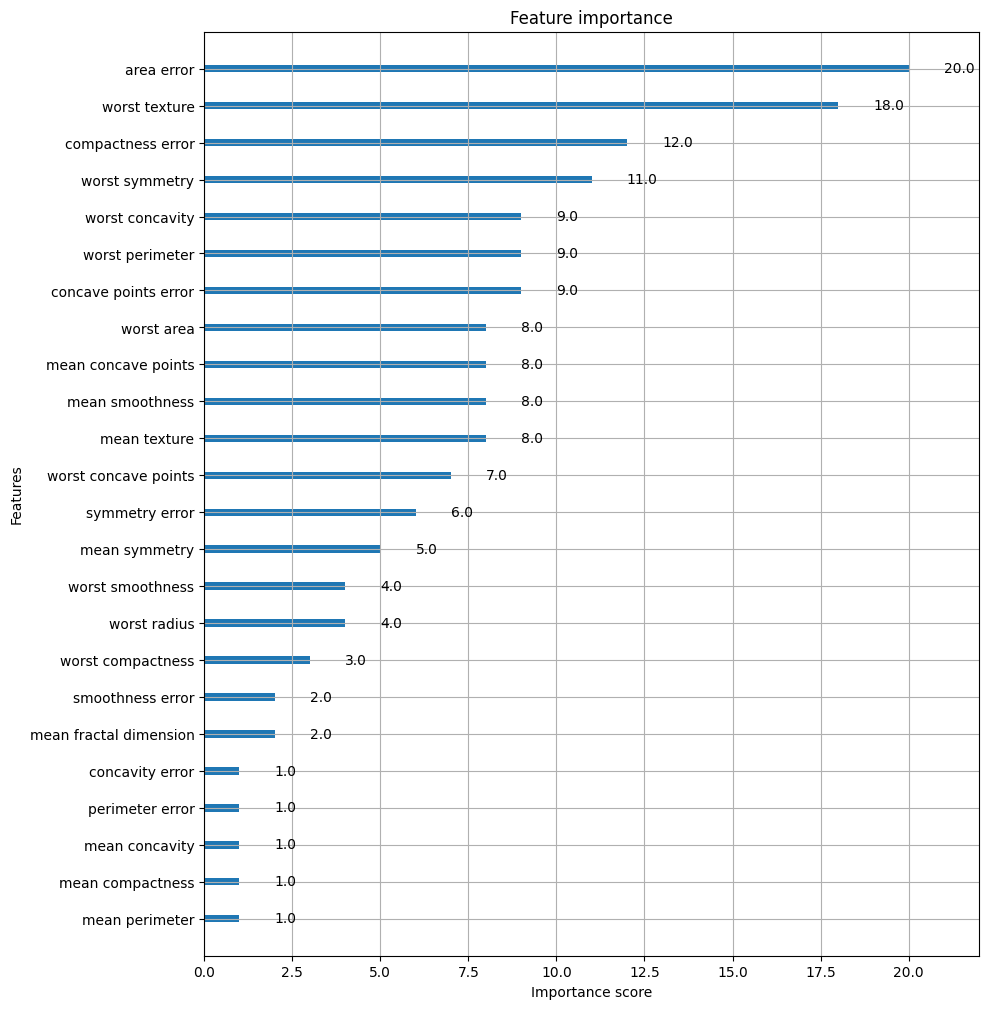

In [28]:
%matplotlib inline

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10,12))  
# XGBoost 모델이 학습 중 어떤 feature를 많이 사용했는지 시각적으로 표현
# --> XGBoost가 학습하면 양성/악성에 어떤 feature가 분류에 가장 기여했는지를 보여줌
plot_importance(xgb_model, ax=ax)                         









# SHAP

# SHAP 개념 설명
## SHAP이란?

SHAP = SHapley Additive exPlanations

“각 feature가 예측값에 얼마나 기여했는지”를 수학적으로 공정하게 나누는 방법

게임 이론에서의 Shapley value를 머신러닝 모델 설명에 적용한 것

## 왜 쓰는가?

개별 예측(로컬 수준) 설명 가능

“이 사람의 예측이 양성 0.93이 된 이유는 반지름, 면적, concavity 때문에 그렇다.”를 숫자로 설명 가능

**전체적으로 어떤 feature가 중요한지(글로벌)**도 볼 수 있음

summary_plot, bar plot 등으로 feature importance를 시각화

모델에 상관 없이(모델 불문) 적용 가능

트리 계열(XGBoost, LightGBM, RandomForest…)에 특히 빠르고 정확한 전용 알고리즘 제공(TreeExplainer)

## 직관적 이해

모델을 하나의 협동 게임이라고 보고,

각 feature를 플레이어라고 생각한다.

특정 데이터 포인트에 대해 예측 값이 나왔을 때,
“기본값(예: 평균 예측값)에서 출발하여 각 feature가 조금씩 기여한 값의 합 = 최종 예측”으로 본다.

이때, “각 feature가 얼마만큼 기여했는지”를 계산한 값이 SHAP value.

In [32]:
! pip install shap

In [36]:
# SHAP 라이브러리 가져오기
import shap     # SHAP은 각 feature 예측에 얼마나 기여했는지를 정량적으로 계산해주는 도구이다.
shap.__version__

shap.initjs()   # 시각화를 웹기반으로 직관적으로 표현

In [34]:
! pip install --upgrade shap

In [37]:
# TreeExplainer 생성
explainer = shap.TreeExplainer(xgb_model) # 이 explainer는 학습된 xgb_model을 분석해서 각 feature의 SHAP value를 계산


In [38]:
# SHAP으로 해석에 사용할 입력 데이터
X_test_sample = X_test.copy()
X_test_sample

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
208,13.11,22.54,87.02,529.4,0.10020,0.14830,0.08705,0.05102,0.1850,0.07310,...,14.550,29.16,99.48,639.3,0.13490,0.44020,0.3162,0.11260,0.4128,0.10760
167,16.78,18.80,109.30,886.3,0.08865,0.09182,0.08422,0.06576,0.1893,0.05534,...,20.050,26.30,130.70,1260.0,0.11680,0.21190,0.2318,0.14740,0.2810,0.07228
89,14.64,15.24,95.77,651.9,0.11320,0.13390,0.09966,0.07064,0.2116,0.06346,...,16.340,18.24,109.40,803.6,0.12770,0.30890,0.2604,0.13970,0.3151,0.08473
100,13.61,24.98,88.05,582.7,0.09488,0.08511,0.08625,0.04489,0.1609,0.05871,...,16.990,35.27,108.60,906.5,0.12650,0.19430,0.3169,0.11840,0.2651,0.07397
88,12.36,21.80,79.78,466.1,0.08772,0.09445,0.06015,0.03745,0.1930,0.06404,...,13.830,30.50,91.46,574.7,0.13040,0.24630,0.2434,0.12050,0.2972,0.09261
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
183,11.41,14.92,73.53,402.0,0.09059,0.08155,0.06181,0.02361,0.1167,0.06217,...,12.370,17.70,79.12,467.2,0.11210,0.16100,0.1648,0.06296,0.1811,0.07427
484,15.73,11.28,102.80,747.2,0.10430,0.12990,0.11910,0.06211,0.1784,0.06259,...,17.010,14.20,112.50,854.3,0.15410,0.29790,0.4004,0.14520,0.2557,0.08181
394,12.10,17.72,78.07,446.2,0.10290,0.09758,0.04783,0.03326,0.1937,0.06161,...,13.560,25.80,88.33,559.5,0.14320,0.17730,0.1603,0.06266,0.3049,0.07081
192,9.72,18.22,60.73,288.1,0.06950,0.02344,0.00000,0.00000,0.1653,0.06447,...,9.968,20.83,62.25,303.8,0.07117,0.02729,0.0000,0.00000,0.1909,0.06559


In [39]:
# SHAP Value 계산
shap_values = explainer.shap_values(X_test_sample)  # 각 feature가 예측한 값에 기여한 정도의 정량적 값을 담고 있다

# 이진 분류의 경우는 shap value가 리스트 형태로 반환되는 경우가 있다. (버전에 따라서 차이 존재)
if isinstance(shap_values, list):
    shap_values_to_use = shap_values[1]
else:
    shap_values_to_use = shap_values  # 배열 형태로 받아오면 그대로 사용


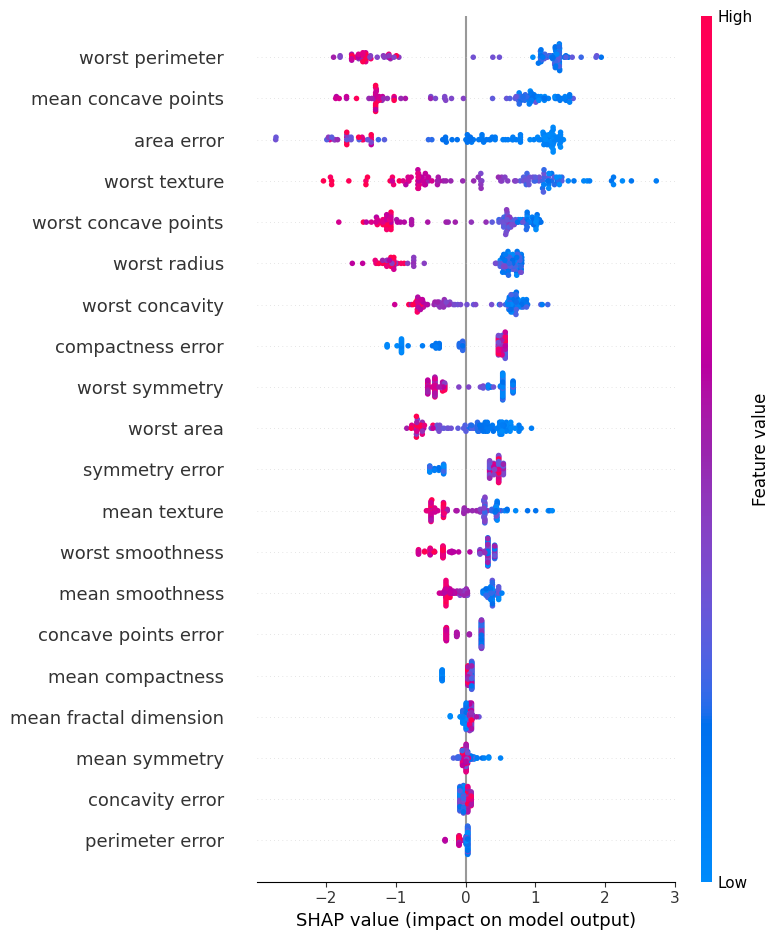

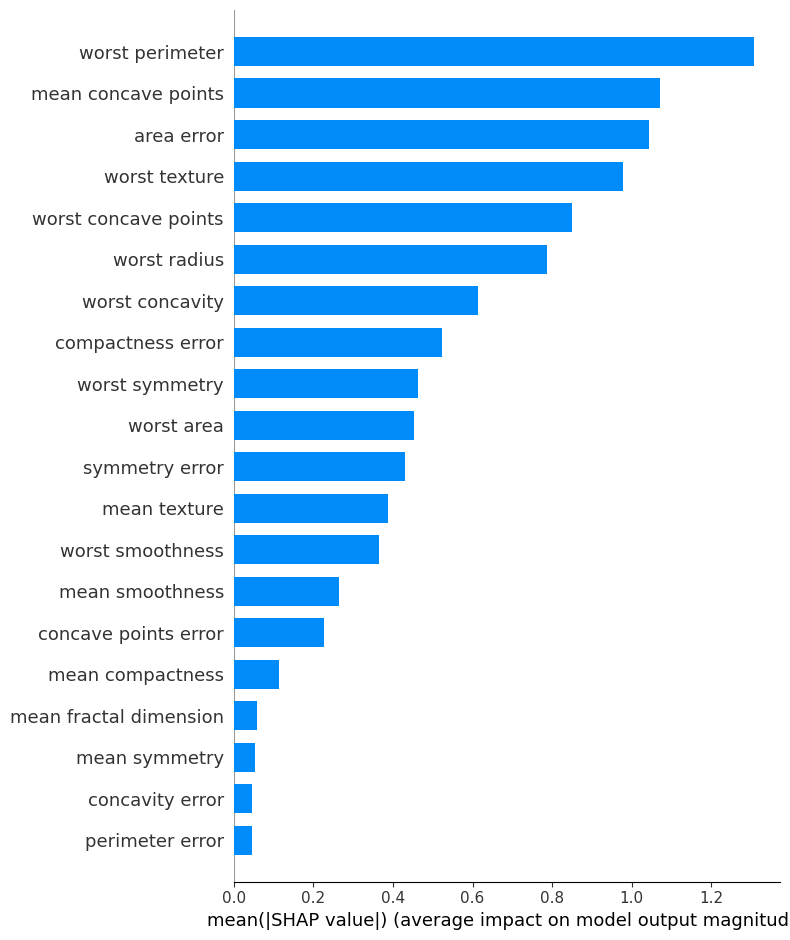

In [40]:
# 시각화
shap.summary_plot(
    shap_values_to_use,   # 각 샘플 피처에 대한 shap 값
    X_test_sample,        # 원본 입력 데이터
    plot_type="dot"       # 도트 형태의 요약 플롯
)

# summary_plot : x축은 SHAP 값(양수/음수 : 예측을 증가/감소시키는 방향), y축은 feature 이름
# 색깔은 해당 feature가 원래 값이 높은지/낮은지 표시 (빨강=값 큼, 파랑=값 작은, 보라=보통)

# feature 중요도를 막대 그래프 형태로 보는 bar plot
shap.summary_plot(
    shap_values_to_use,    # SHAP 값
    X_test_sample,         # 입력 데이터
    plot_type="bar"        # bar 타입을 선택하여 평균 절대 SHAP값을 기준으로 중요도 그림 <-- SHAP 값이 클수록 모델 예측에 큰 영향을 미친다는 의미
)

# 개별 샘플 데이터에 대한 로컬 설명 - force_plot
idx = 0   #

shap.force_plot(
    explainer.expected_value,              # 기준값
    shap_values_to_use[idx, :],            # 선택한 샘플의 각 피처 별 shap 값 전달 (벡터 형태)
    X_test_sample.iloc[idx, :]             # 선택한 샘플의 원 피처 값들을 전달 (벡터 형태)
)



1. 그래프 전체 구조 이해

이 SHAP summary dot plot은 다음 요소로 구성됩니다:

Y축: Feature 목록 (중요한 순서대로 정렬됨)

X축: SHAP value
→ 예측 결과에 대한 feature의 “기여도”

양수(오른쪽): 해당 feature가 양성(benign) 쪽으로 확률을 증가시킴

음수(왼쪽): 해당 feature가 악성(malignant) 쪽으로 확률을 증가시킴

색깔: 원래 feature 값의 크기

빨강 = 큰 값

파랑 = 작은 값

점 하나 = 테스트 데이터 1개의 feature 값

즉,
각 점은 ‘특정 샘플의 그 feature가 예측을 어느 방향으로 얼마나 밀었는지’ 나타내는 것입니다.

 2. X축: SHAP Value 의미
SHAP 값 방향	해석
양수(+)	모델이 양성(1) 쪽으로 예측하도록 기여
음수(-)	모델이 악성(0) 쪽으로 예측하도록 기여

예:
SHAP = +1.0 이면
→ 이 feature가 “그 샘플을 양성이라고 판단하도록 1.0만큼 밀어줌”

 3. 색: Feature 원래 값

빨간색 (High) → 해당 feature의 값이 높다

파란색 (Low) → 해당 feature의 값이 낮다

보라색 → 중간값

이 색은 feature의 원래 값이 높을 때 예측에 어떤 영향을 주는지 해석하는 데 매우 중요함.

 4. 주요 Feature 해석 (중요도 순으로 분석)

아래 해석은 그래프에 나타난 패턴을 기반으로 SHAP 방식으로 “모델이 실제로 어떻게 판단하는지”를 설명하는 것입니다.

 1) mean concave points

가장 중요도가 높은 feature

**빨간 점(값이 높은 샘플)**은 대부분 오른쪽(+ 방향) → 양성 확률 증가

파란 점(값 낮음)은 왼쪽(음수)

➡ mean concave points 값이 클수록 양성으로 판단될 가능성이 증가
(특정 데이터셋에서는 concave points가 클 때 benign일 수도 있음. 데이터 특성에 따라 반대인 경우도 있음)

 2) worst perimeter

값이 클수록(빨간색) → 오른쪽(양수)

값이 작으면(파란색) → 왼쪽(음수)

➡ 둘레가 긴 종양은 양성 쪽으로 기여하는 패턴
(이 부분은 데이터셋 특성에 따라 benign일 때 둘레가 크다는 경향을 모델이 학습한 것)

 3) worst radius

worst radius가 큰 샘플(빨간)이 대부분 양수

작은 샘플(파란)은 음수

➡ 반지름이 큰 경우 모델은 양성(1) 쪽으로 판단하는 경향

 4) worst texture

worst texture 높은 값(빨강)도 양수 방향으로 기여

낮은 값(파랑)은 대체로 음수

➡ texture(표면 불균일성)가 클수록 양성 쪽으로 영향

 5) area error

값이 큰 경우(빨강)는 오른쪽(양수)

작은 값(파랑)은 왼쪽

➡ 면적 변동성이 크면 양성으로 기여

 전반적인 패턴

대부분의 top feature에서 공통적으로 보이는 현상:

빨간 점(high value) → 양수 방향

파란 점(low value) → 음수 방향

즉,

해당 데이터셋에서는 feature 값이 클수록 양성(benign)으로 분류하는 패턴을 XGBoost가 학습함

이는 위스콘신 데이터에서 라벨(0=악성, 1=양성)의 분포 특성 및 샘플들의 실제 값에 의해 결정됩니다.

 5. 하위 중요도 Feature 해석
mean concavity, mean compactness 등

점들이 중심(0 근처)에 밀집 → 영향이 크지 않음

SHAP 값의 절대값이 작다 → 예측을 크게 바꾸지는 않음

radius error, texture error 등

SHAP 분포가 거의 0 근처

모델이 거의 사용하지 않는 특징

 6. SHAP summary plot 종합 해석 (최종 요약)

mean concave points, worst perimeter, worst radius 등이 예측에 가장 큰 영향

feature 값이 높을수록(빨간색), 대부분 양성(1) 방향으로 기여

feature 값이 낮을수록(파란색), 대부분 악성(0) 방향으로 기여

하위 feature들은 SHAP 값이 작아 예측에 별 영향 없음

모델은 “종양 크기 / 모양의 오목함 / 둘레 / 반경”과 같은 특징에 가장 의존함

SHAP plot을 통해

글로벌: 전체 feature 중요도

로컬: 각 샘플이 어떻게 판단되었는지
를 동시에 잘 보여줌